Title: LEE_Detection.ipynb

Purpose: Identifiy Low Energy Events with varying lengths from the model output data

Author: Onno Nennecke on 21.03.2025 Modified: 10.09.2025

Input data: 

- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'

Output data:

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob


### Read Model output data

In [2]:
# path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
# path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'

ts_datasets = xr.open_dataset(path)
ts_datasets.load()

<xarray.Dataset> Size: 60MB
Dimensions:        (ESM_run: 194, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'hist'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'wwd'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 -2.722 ... nan nan
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.204e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... nan nan nan
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... nan nan nan
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 -2.629 ... nan nan
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 -0.9483 ... nan nan
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 61.19 69.34
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 534.3 529.0
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 22.93 49.09
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 618.5 647.4
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 -907.2 ... nan nan
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 907.2 ... 659.8 556.8

In [3]:
# path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'
# files = sorted(glob.glob(path + '*.nc'))
# # files = files[:60] + files[61:]
# ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim = 'ESM_run')
# ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

# ts_datasets

#### Identification of low energy events

In [4]:
# RL = ts_datasets['Residual_load_adj']
RL = ts_datasets['Residual_load']

RL.values

array([[ 609.48011372,  793.41464988,  907.1603086 , ..., 1232.37851857,
        1066.37782121,  592.87906948],
       [ 462.58176097,  475.54562743,  537.65952392, ...,  778.522393  ,
         242.01169521,  -92.22855004],
       [ 325.23504813,  867.82497075, 1200.82346924, ..., 1283.62115454,
        1260.91735393,  601.21880191],
       ...,
       [1278.89246127, 1260.97681835, 1403.45791958, ..., 1212.56949988,
        1300.25157802, 1457.76143367],
       [ 548.54142222, -109.18751349, -210.90010476, ..., 1306.70204962,
        1506.6195729 , 1319.56557544],
       [ 768.47225   ,  679.20575   ,  736.91175   , ...,  784.75025   ,
         659.8235    ,  556.83375   ]])

In [5]:
# Calculate the rolling means
ts_datasets['RL_mov_avg_7'] = RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
ts_datasets['RL_mov_avg_14'] = RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()
# ts_datasets

In [6]:
ts_datasets.load()

<xarray.Dataset> Size: 71MB
Dimensions:        (ESM_run: 194, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'hist'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'wwd'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables: (12/14)
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 -2.722 ... nan nan
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.204e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... nan nan nan
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... nan nan nan
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 -2.629 ... nan nan
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 -0.9483 ... nan nan
    ...             ...
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 22.93 49.09
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 618.5 647.4
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 -907.2 ... nan nan
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 907.2 ... 659.8 556.8
    RL_mov_avg_7   (ESM_run, time) float64 6MB nan nan nan ... 840.9 866.0 832.5
    RL_mov_avg_14  (ESM_run, time) float64 6MB nan nan nan ... 635.2 655.1 640.2

In [7]:
print(ts_datasets.sel(ESM_run='ERA5_hist_week').Residual_load.values[0:10])
print(ts_datasets.sel(ESM_run='ERA5_hist_week').RL_mov_avg_7.values[0:10])

[ 533.62954852 -124.66275289  290.84286213  480.36899007 1092.6153132
 1247.41532728 1042.96360159  458.53011108 -331.65915914 -372.27686762]
[         nan          nan          nan          nan          nan
          nan 651.88184141 641.15335035 611.58243517 516.85104521]


In [8]:
(777.52873511 + 96.93869171 + 535.2921622 + 736.15298075 + 1242.50983711 + 1350.38753392 + 1179.10597113) / 7

845.4165588471429

In [8]:
ts_datasets.ESM_run

<xarray.DataArray 'ESM_run' (ESM_run: 194)> Size: 18kB
array(['ACCESS-CM2_r1i1p1f1', 'ACCESS-CM2_r4i1p1f1', 'ACCESS-CM2_r5i1p1f1',
       'BCC-CSM2-MR_r1i1p1f1', 'CESM2_LE2-1001_001', 'CESM2_LE2-1011_001',
       'CESM2_LE2-1021_002', 'CESM2_LE2-1031_002', 'CESM2_LE2-1041_003',
       'CESM2_LE2-1051_003', 'CESM2_LE2-1061_004', 'CESM2_LE2-1071_004',
       'CESM2_LE2-1081_005', 'CESM2_LE2-1091_005', 'CESM2_LE2-1101_006',
       'CESM2_LE2-1111_006', 'CESM2_LE2-1121_007', 'CESM2_LE2-1131_007',
       'CESM2_LE2-1141_008', 'CESM2_LE2-1151_008', 'CESM2_LE2-1161_009',
       'CESM2_LE2-1171_009', 'CESM2_LE2-1181_010', 'CESM2_LE2-1191_010',
       'CESM2_LE2-1231_001', 'CESM2_LE2-1231_002', 'CESM2_LE2-1231_003',
       'CESM2_LE2-1231_004', 'CESM2_LE2-1231_005', 'CESM2_LE2-1231_006',
       'CESM2_LE2-1231_007', 'CESM2_LE2-1231_008', 'CESM2_LE2-1231_009',
       'CESM2_LE2-1231_010', 'CESM2_LE2-1231_011', 'CESM2_LE2-1231_012',
       'CESM2_LE2-1231_013', 'CESM2_LE2-1231_014', 'CESM2_LE2-1231_015',
       'CESM2_LE2-1231_016', 'CESM2_LE2-1231_017', 'CESM2_LE2-1231_018',
       'CESM2_LE2-1231_019', 'CESM2_LE2-1231_020', 'CESM2_LE2-1251_001',
       'CESM2_LE2-1251_002', 'CESM2_LE2-1251_003', 'CESM2_LE2-1251_004',
       'CESM2_LE2-1251_005', 'CESM2_LE2-1251_006', 'CESM2_LE2-1251_007',
       'CESM2_LE2-1251_008', 'CESM2_LE2-1251_009', 'CESM2_LE2-1251_010',
       'CESM2_LE2-1251_011', 'CESM2_LE2-1251_012', 'CESM2_LE2-1251_013',
       'CESM2_LE2-1251_014', 'CESM2_LE2-1251_015', 'CESM2_LE2-1251_016',
       'CESM2_LE2-1251_017', 'CESM2_LE2-1251_018', 'CESM2_LE2-1251_019',
       'CESM2_LE2-1251_020', 'CESM2_LE2-1281_001', 'CESM2_LE2-1281_002',
       'CESM2_LE2-1281_003', 'CESM2_LE2-1281_004', 'CESM2_LE2-1281_005',
       'CESM2_LE2-1281_006', 'CESM2_LE2-1281_007', 'CESM2_LE2-1281_008',
       'CESM2_LE2-1281_009', 'CESM2_LE2-1281_010', 'CESM2_LE2-1281_011',
       'CESM2_LE2-1281_012', 'CESM2_LE2-1281_013', 'CESM2_LE2-1281_014',
       'CESM2_LE2-1281_015', 'CESM2_LE2-1281_016', 'CESM2_LE2-1281_017',
       'CESM2_LE2-1281_018', 'CESM2_LE2-1281_019', 'CESM2_LE2-1281_020',
       'CESM2_LE2-1301_001', 'CESM2_LE2-1301_002', 'CESM2_LE2-1301_003',
       'CESM2_LE2-1301_004', 'CESM2_LE2-1301_005', 'CESM2_LE2-1301_006',
       'CESM2_LE2-1301_007', 'CESM2_LE2-1301_008', 'CESM2_LE2-1301_009',
       'CESM2_LE2-1301_010', 'CESM2_LE2-1301_011', 'CESM2_LE2-1301_012',
       'CESM2_LE2-1301_013', 'CESM2_LE2-1301_014', 'CESM2_LE2-1301_015',
       'CESM2_LE2-1301_016', 'CESM2_LE2-1301_017', 'CESM2_LE2-1301_018',
       'CESM2_LE2-1301_019', 'CESM2_LE2-1301_020', 'CESM2_r10i1p1f1',
       'CESM2_r11i1p1f1', 'CESM2_r4i1p1f1', 'EC-Earth3_r101i1p1f1',
       'EC-Earth3_r102i1p1f1', 'EC-Earth3_r103i1p1f1', 'EC-Earth3_r104i1p1f1',
       'EC-Earth3_r105i1p1f1', 'EC-Earth3_r106i1p1f1', 'EC-Earth3_r107i1p1f1',
       'EC-Earth3_r108i1p1f1', 'EC-Earth3_r109i1p1f1', 'EC-Earth3_r110i1p1f1',
       'EC-Earth3_r111i1p1f1', 'EC-Earth3_r112i1p1f1', 'EC-Earth3_r113i1p1f1',
       'EC-Earth3_r114i1p1f1', 'EC-Earth3_r115i1p1f1', 'EC-Earth3_r116i1p1f1',
       'EC-Earth3_r117i1p1f1', 'EC-Earth3_r118i1p1f1', 'EC-Earth3_r119i1p1f1',
       'EC-Earth3_r120i1p1f1', 'EC-Earth3_r121i1p1f1', 'EC-Earth3_r122i1p1f1',
       'EC-Earth3_r123i1p1f1', 'EC-Earth3_r124i1p1f1', 'EC-Earth3_r125i1p1f1',
       'EC-Earth3_r126i1p1f1', 'EC-Earth3_r127i1p1f1', 'EC-Earth3_r128i1p1f1',
       'EC-Earth3_r129i1p1f1', 'EC-Earth3_r130i1p1f1', 'EC-Earth3_r131i1p1f1',
       'EC-Earth3_r132i1p1f1', 'EC-Earth3_r133i1p1f1', 'EC-Earth3_r134i1p1f1',
       'EC-Earth3_r135i1p1f1', 'EC-Earth3_r136i1p1f1', 'EC-Earth3_r137i1p1f1',
       'EC-Earth3_r138i1p1f1', 'EC-Earth3_r139i1p1f1', 'EC-Earth3_r140i1p1f1',
       'EC-Earth3_r141i1p1f1', 'EC-Earth3_r142i1p1f1', 'EC-Earth3_r143i1p1f1',
       'EC-Earth3_r144i1p1f1', 'EC-Earth3_r145i1p1f1', 'EC-Earth3_r146i1p1f1',
       'EC-Earth3_r147i1p1f1', 'EC-Earth3_r148i1p1f1', 'EC-Earth3_r149i1p1f1',
       'EC-Earth3_r150i1p1f1', 'EC-Earth3_r1i1p1f1', 'EC

##### Threshold Calculation

In [8]:
thresh_perc = 0.95

In [9]:
# Select all ESM_runs with period 'week'
ts_datasets_week = ts_datasets.sel(ESM_run=ts_datasets.ESM_run[ts_datasets.period == 'week'])
# RL_week = ts_datasets_week['Residual_load_adj']
RL_week = ts_datasets_week['Residual_load']
threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week

np.float64(1319.138650687668)

In [10]:
# Select the SMARD data
ts_datasets_SMARD = ts_datasets.sel(ESM_run='SMARD_hist')
# RL_SMARD = ts_datasets_SMARD['Residual_load_adj']
RL_SMARD = ts_datasets_SMARD['Residual_load']
threshold_SMARD = np.quantile(RL_SMARD.values.flatten(), thresh_perc)
threshold_SMARD

np.float64(1332.1978625)

In [11]:
# Select the ERA5_week data
ts_datasets_ERA5_week = ts_datasets.sel(ESM_run='ERA5_hist_week')
# RL_ERA5_week = ts_datasets_ERA5_week['Residual_load_adj']
RL_ERA5_week = ts_datasets_ERA5_week['Residual_load']
threshold_ERA5_week = np.quantile(RL_ERA5_week.values.flatten(), thresh_perc)
threshold_ERA5_week

np.float64(1306.5611116215875)

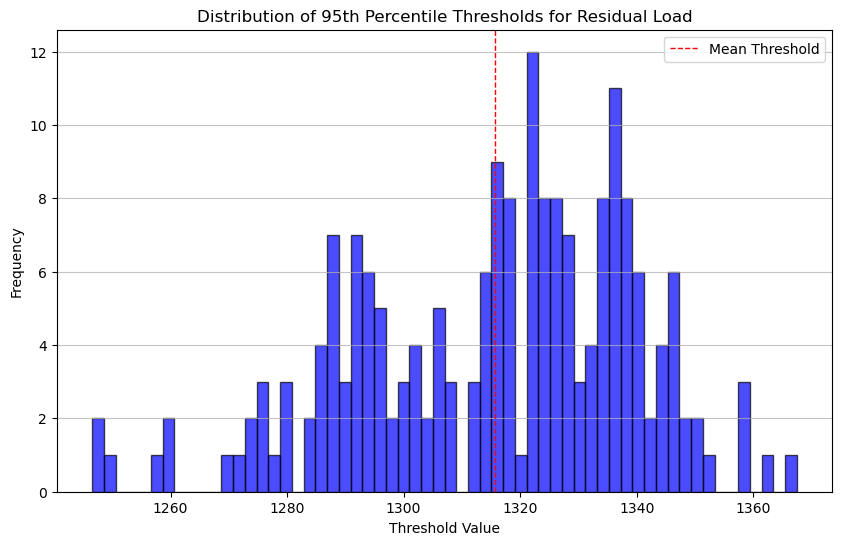

In [12]:
# Test
threshs = []
for esm_run in ts_datasets.ESM_run.values:
    ts_datasets_tst = ts_datasets.sel(ESM_run=esm_run)
    # RL_tst = ts_datasets_tst['Residual_load_adj']
    RL_tst = ts_datasets_tst['Residual_load']
    threshold_tst = np.quantile(RL_tst.values.flatten(), thresh_perc)
    threshs.append(threshold_tst)

# Plot the thresholds as a distribution
plt.figure(figsize=(10, 6))
plt.hist(threshs, bins=60, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of 95th Percentile Thresholds for Residual Load')
plt.xlabel('Threshold Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(np.mean(threshs), color='red', linestyle='dashed', linewidth=1, label='Mean Threshold')
plt.legend()
plt.show()

In [13]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool_1 = xr.where(RL > threshold_week, True, False)
exceed_bool_7 = xr.where(RL_mov_avg_7 > threshold_week, True, False)
exceed_bool_14 = xr.where(RL_mov_avg_14 > threshold_week, True, False)

In [15]:
# Look for events without any rolling mean


# Count number of true values overall
count_exceed_1 = exceed_bool_1.sum(dim='time').sum(dim='ESM_run')
count_exceed_1.values
# exceed_bool_1.time
# np.zeros_like(exceed_bool_1, dtype=int)

array(35426)

### Days above threshold (dat) 

- Take each day as its own event (not really events but just days above threshold)

In [16]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_1.values)
n_dat = run_idx.size

# 2) Create a flat counter 1…n_dat
labels = np.arange(1, n_dat + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat = np.zeros_like(exceed_bool_1.values, dtype=int)
dat[run_idx, time_idx] = labels

# wrap back into an xarray
dat = xr.DataArray(
    dat,
    coords=exceed_bool_1.coords,
    dims=exceed_bool_1.dims,
    name="dat"
)

n_dat = n_dat
dat

<xarray.DataArray 'dat' (ESM_run: 194, time: 3650)> Size: 6MB
array([[    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       ...,
       [    0,     0, 34817, ...,     0,     0, 35006],
       [    0,     0,     0, ...,     0, 35222, 35223],
       [    0,     0,     0, ...,     0,     0,     0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [17]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_7.values)
n_dat_7 = run_idx.size

# 2) Create a flat counter 1…n_dat_7
labels = np.arange(1, n_dat_7 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_7 = np.zeros_like(exceed_bool_7.values, dtype=int)
dat_7[run_idx, time_idx] = labels

# wrap back into an xarray
dat_7 = xr.DataArray(
    dat_7,
    coords=exceed_bool_7.coords,
    dims=exceed_bool_7.dims,
    name="dat_7"
)

n_dat_7 = n_dat_7
dat_7

<xarray.DataArray 'dat_7' (ESM_run: 194, time: 3650)> Size: 6MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [18]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_14.values)
n_dat_14 = run_idx.size

# 2) Create a flat counter 1…n_dat_14
labels = np.arange(1, n_dat_14 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_14 = np.zeros_like(exceed_bool_14.values, dtype=int)
dat_14[run_idx, time_idx] = labels

# wrap back into an xarray
dat_14 = xr.DataArray(
    dat_14,
    coords=exceed_bool_14.coords,
    dims=exceed_bool_14.dims,
    name="dat_14"
)

n_dat_14 = n_dat_14
dat_14

<xarray.DataArray 'dat_14' (ESM_run: 194, time: 3650)> Size: 6MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

### Events with rolling mean of 1 above threshold (events_vl) = events with varying length 

In [19]:
# Look for events without any rolling mean

events_vl = np.zeros_like(exceed_bool_1, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_1.ESM_run.values:
    run_data = exceed_bool_1.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_vl[counter] = labeled_segment
    counter += 1

n_events_vl = current_label - 1
n_events_vl



17340

In [20]:
def LEE_detection(events, n_events, t=RL['time'].values, dur = 7, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue
            print(f"Processing event {ev} for run {i+1}/{len(RL.ESM_run)}")

            end_idx = np.where(events[i] == ev)[0][0]
            start_idx = end_idx - dur + 1

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)


In [21]:
LEE_dat = LEE_detection(dat, n_dat, dur = 1)

Processing event 1 for run 1/194
Processing event 2 for run 1/194
Processing event 3 for run 1/194
Processing event 4 for run 1/194
Processing event 5 for run 1/194
Processing event 6 for run 1/194
Processing event 7 for run 1/194
Processing event 8 for run 1/194
Processing event 9 for run 1/194
Processing event 10 for run 1/194
Processing event 11 for run 1/194
Processing event 12 for run 1/194
Processing event 13 for run 1/194
Processing event 14 for run 1/194
Processing event 15 for run 1/194
Processing event 16 for run 1/194
Processing event 17 for run 1/194
Processing event 18 for run 1/194
Processing event 19 for run 1/194
Processing event 20 for run 1/194
Processing event 21 for run 1/194
Processing event 22 for run 1/194
Processing event 23 for run 1/194
Processing event 24 for run 1/194
Processing event 25 for run 1/194
Processing event 26 for run 1/194
Processing event 27 for run 1/194
Processing event 28 for run 1/194
Processing event 29 for run 1/194
Processing event 30 for

In [22]:
LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv', index=False)
# LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat.csv', index=False)

LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35421,2024-01-11,2024-01-11,2024-01-11,3295,3295,3295,1,1346.653250,1346.653250,0.0,1346.653250,35422,SMARD,SMARD_hist,2024,11
35422,2024-11-06,2024-11-06,2024-11-06,3594,3594,3594,1,1370.874500,1370.874500,0.0,1370.874500,35423,SMARD,SMARD_hist,2024,310
35423,2024-11-07,2024-11-07,2024-11-07,3595,3595,3595,1,1353.773750,1353.773750,0.0,1353.773750,35424,SMARD,SMARD_hist,2024,311
35424,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.075500,1425.075500,0.0,1425.075500,35425,SMARD,SMARD_hist,2024,345


In [23]:
LEE_dat_7 = LEE_detection(dat_7, n_dat_7, dur = 7)

Processing event 1 for run 1/194
Processing event 2 for run 1/194
Processing event 3 for run 1/194
Processing event 4 for run 1/194
Processing event 5 for run 1/194
Processing event 6 for run 1/194
Processing event 7 for run 1/194
Processing event 8 for run 1/194
Processing event 9 for run 1/194
Processing event 10 for run 1/194
Processing event 11 for run 1/194
Processing event 12 for run 1/194
Processing event 13 for run 1/194
Processing event 14 for run 1/194
Processing event 15 for run 1/194
Processing event 16 for run 1/194
Processing event 17 for run 1/194
Processing event 18 for run 1/194
Processing event 19 for run 1/194
Processing event 20 for run 1/194
Processing event 21 for run 1/194
Processing event 22 for run 1/194
Processing event 23 for run 1/194
Processing event 24 for run 1/194
Processing event 25 for run 1/194
Processing event 26 for run 1/194
Processing event 27 for run 1/194
Processing event 28 for run 1/194
Processing event 29 for run 1/194
Processing event 30 for

In [24]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_7['ESM_run'].ne(LEE_dat_7['ESM_run'].shift())
not_consecutive = (LEE_dat_7['date_start'] - LEE_dat_7['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_7['event'] = is_new_event.cumsum()
LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2016-12-26,2016-12-20 00:00:00.000000004,718,724,722,7,1423.669022,1352.595015,74.060716,9468.165104,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000003,719,725,722,7,1423.669022,1363.985879,60.214536,9547.901154,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2017-12-01,2017-12-07,2017-12-01 00:00:00.000000005,1064,1070,1069,7,1430.660269,1336.117805,54.253834,9352.824634,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,335
3,2018-01-18,2018-01-24,2018-01-18 00:00:00.000000002,1112,1118,1114,7,1414.239417,1340.338876,85.408675,9382.372131,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,18
4,2018-01-19,2018-01-25,2018-01-19 00:00:00.000000001,1113,1119,1114,7,1414.239417,1322.396611,123.223309,9256.776279,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10388,2018-02-03,2018-02-09,2018-02-03 00:00:00.000000004,1128,1134,1132,7,1500.555000,1328.324714,160.849718,9298.273000,2388,SMARD,SMARD_hist,2018,34
10389,2018-02-04,2018-02-10,2018-02-04 00:00:00.000000003,1129,1135,1132,7,1500.555000,1328.256464,160.901258,9297.795250,2388,SMARD,SMARD_hist,2018,35
10390,2019-01-18,2019-01-24,2019-01-18 00:00:00.000000006,1477,1483,1483,7,1568.968250,1336.794464,141.330911,9357.561250,2389,SMARD,SMARD_hist,2019,18
10391,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1568.968250,1360.466000,140.394451,9523.262000,2389,SMARD,SMARD_hist,2019,19


In [25]:
LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv', index=False)
# LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_7.csv', index=False)

LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2016-12-26,2016-12-20 00:00:00.000000004,718,724,722,7,1423.669022,1352.595015,74.060716,9468.165104,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000003,719,725,722,7,1423.669022,1363.985879,60.214536,9547.901154,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2017-12-01,2017-12-07,2017-12-01 00:00:00.000000005,1064,1070,1069,7,1430.660269,1336.117805,54.253834,9352.824634,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,335
3,2018-01-18,2018-01-24,2018-01-18 00:00:00.000000002,1112,1118,1114,7,1414.239417,1340.338876,85.408675,9382.372131,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,18
4,2018-01-19,2018-01-25,2018-01-19 00:00:00.000000001,1113,1119,1114,7,1414.239417,1322.396611,123.223309,9256.776279,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10388,2018-02-03,2018-02-09,2018-02-03 00:00:00.000000004,1128,1134,1132,7,1500.555000,1328.324714,160.849718,9298.273000,2388,SMARD,SMARD_hist,2018,34
10389,2018-02-04,2018-02-10,2018-02-04 00:00:00.000000003,1129,1135,1132,7,1500.555000,1328.256464,160.901258,9297.795250,2388,SMARD,SMARD_hist,2018,35
10390,2019-01-18,2019-01-24,2019-01-18 00:00:00.000000006,1477,1483,1483,7,1568.968250,1336.794464,141.330911,9357.561250,2389,SMARD,SMARD_hist,2019,18
10391,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1568.968250,1360.466000,140.394451,9523.262000,2389,SMARD,SMARD_hist,2019,19


In [26]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_7.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_7_max_cum_RL = LEE_dat_7.loc[idx].reset_index(drop=True)
LEE_dat_7_max_cum_RL


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000003,719,725,722,7,1423.669022,1363.985879,60.214536,9547.901154,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
1,2017-12-01,2017-12-07,2017-12-01 00:00:00.000000005,1064,1070,1069,7,1430.660269,1336.117805,54.253834,9352.824634,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,335
2,2018-01-18,2018-01-24,2018-01-18 00:00:00.000000002,1112,1118,1114,7,1414.239417,1340.338876,85.408675,9382.372131,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,18
3,2019-01-14,2019-01-20,2019-01-14 00:00:00.000000002,1473,1479,1475,7,1474.813990,1345.544533,146.904703,9418.811732,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,14
4,2019-12-08,2019-12-14,2019-12-08 00:00:00.000000002,1801,1807,1803,7,1476.866057,1377.010345,118.987333,9639.072416,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2384,2016-11-07,2016-11-13,2016-11-07 00:00:00.000000001,675,681,676,7,1429.755000,1326.488500,135.234633,9285.419500,2385,SMARD,SMARD_hist,2016,311
2385,2016-12-13,2016-12-19,2016-12-13 00:00:00.000000001,711,717,712,7,1505.451750,1372.092071,125.081966,9604.644500,2386,SMARD,SMARD_hist,2016,347
2386,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000005,748,754,753,7,1627.713750,1460.625714,148.305625,10224.380000,2387,SMARD,SMARD_hist,2017,19
2387,2018-02-03,2018-02-09,2018-02-03 00:00:00.000000004,1128,1134,1132,7,1500.555000,1328.324714,160.849718,9298.273000,2388,SMARD,SMARD_hist,2018,34


In [27]:
# LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_7_selection.csv', index=False)
LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv', index=False)


In [28]:
LEE_dat_14 = LEE_detection(dat_14, n_dat_14, dur = 14)

Processing event 1 for run 1/194
Processing event 2 for run 1/194
Processing event 3 for run 2/194
Processing event 4 for run 2/194
Processing event 5 for run 2/194
Processing event 6 for run 2/194
Processing event 7 for run 2/194
Processing event 8 for run 2/194
Processing event 9 for run 2/194
Processing event 10 for run 2/194
Processing event 11 for run 2/194
Processing event 12 for run 2/194
Processing event 13 for run 2/194
Processing event 14 for run 2/194
Processing event 15 for run 2/194
Processing event 16 for run 2/194
Processing event 17 for run 2/194
Processing event 18 for run 2/194
Processing event 19 for run 2/194
Processing event 20 for run 2/194
Processing event 21 for run 2/194
Processing event 22 for run 4/194
Processing event 23 for run 4/194
Processing event 24 for run 4/194
Processing event 25 for run 4/194
Processing event 26 for run 4/194
Processing event 27 for run 4/194
Processing event 28 for run 4/194
Processing event 29 for run 4/194
Processing event 30 for

In [34]:
LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2017-01-02,2016-12-20 00:00:00.000000004,718,731,722,14,1423.669022,1319.864033,105.335396,18478.096467,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2019-12-02,2019-12-15,2019-12-02 00:00:00.000000008,1795,1808,1803,14,1476.866057,1331.478120,167.095233,18640.693676,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,336
2,2019-11-06,2019-11-19,2019-11-06 00:00:00.000000013,1769,1782,1782,14,1420.984801,1324.802925,97.586944,18547.240945,3,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,310
3,2019-11-07,2019-11-20,2019-11-07 00:00:00.000000012,1770,1783,1782,14,1420.984801,1327.937657,98.867722,18591.127202,4,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,311
4,2019-11-10,2019-11-23,2019-11-10 00:00:00.000000013,1773,1786,1786,14,1421.173476,1319.167365,105.864651,18468.343104,5,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3968,2017-01-19,2017-02-01,2017-01-19 00:00:00.000000005,748,761,753,14,1627.713750,1363.704589,184.081687,19091.864250,3969,SMARD,SMARD_hist,2017,19
3969,2017-01-20,2017-02-02,2017-01-20 00:00:00.000000004,749,762,753,14,1627.713750,1351.205214,180.848665,18916.873000,3970,SMARD,SMARD_hist,2017,20
3970,2017-01-21,2017-02-03,2017-01-21 00:00:00.000000003,750,763,753,14,1627.713750,1343.288964,177.702747,18806.045500,3971,SMARD,SMARD_hist,2017,21
3971,2017-01-22,2017-02-04,2017-01-22 00:00:00.000000002,751,764,753,14,1627.713750,1330.026482,188.763893,18620.370750,3972,SMARD,SMARD_hist,2017,22


In [29]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_14['ESM_run'].ne(LEE_dat_14['ESM_run'].shift())
not_consecutive = (LEE_dat_14['date_start'] - LEE_dat_14['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_14['event'] = is_new_event.cumsum()
# LEE_dat_14

In [30]:
LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv', index=False)
# LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_14.csv', index=False)

LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2017-01-02,2016-12-20 00:00:00.000000004,718,731,722,14,1423.669022,1319.864033,105.335396,18478.096467,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2019-12-02,2019-12-15,2019-12-02 00:00:00.000000008,1795,1808,1803,14,1476.866057,1331.478120,167.095233,18640.693676,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,336
2,2019-11-06,2019-11-19,2019-11-06 00:00:00.000000013,1769,1782,1782,14,1420.984801,1324.802925,97.586944,18547.240945,3,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,310
3,2019-11-07,2019-11-20,2019-11-07 00:00:00.000000012,1770,1783,1782,14,1420.984801,1327.937657,98.867722,18591.127202,3,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,311
4,2019-11-10,2019-11-23,2019-11-10 00:00:00.000000013,1773,1786,1786,14,1421.173476,1319.167365,105.864651,18468.343104,4,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,2017-01-19,2017-02-01,2017-01-19 00:00:00.000000005,748,761,753,14,1627.713750,1363.704589,184.081687,19091.864250,727,SMARD,SMARD_hist,2017,19
3971,2017-01-20,2017-02-02,2017-01-20 00:00:00.000000004,749,762,753,14,1627.713750,1351.205214,180.848665,18916.873000,727,SMARD,SMARD_hist,2017,20
3972,2017-01-21,2017-02-03,2017-01-21 00:00:00.000000003,750,763,753,14,1627.713750,1343.288964,177.702747,18806.045500,727,SMARD,SMARD_hist,2017,21
3973,2017-01-22,2017-02-04,2017-01-22 00:00:00.000000002,751,764,753,14,1627.713750,1330.026482,188.763893,18620.370750,727,SMARD,SMARD_hist,2017,22


In [31]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_14.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_14_max_cum_RL = LEE_dat_14.loc[idx].reset_index(drop=True)
LEE_dat_14_max_cum_RL

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2017-01-02,2016-12-20 00:00:00.000000004,718,731,722,14,1423.669022,1319.864033,105.335396,18478.096467,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2019-12-02,2019-12-15,2019-12-02 00:00:00.000000008,1795,1808,1803,14,1476.866057,1331.478120,167.095233,18640.693676,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,336
2,2019-11-07,2019-11-20,2019-11-07 00:00:00.000000012,1770,1783,1782,14,1420.984801,1327.937657,98.867722,18591.127202,3,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,311
3,2019-11-10,2019-11-23,2019-11-10 00:00:00.000000013,1773,1786,1786,14,1421.173476,1319.167365,105.864651,18468.343104,4,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,314
4,2019-11-12,2019-11-25,2019-11-12 00:00:00.000000011,1775,1788,1786,14,1421.173476,1319.171241,103.535796,18468.397371,5,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2022-01-15,2022-01-28,2022-01-15 00:00:00.000000001,2569,2582,2570,14,1497.039850,1334.505435,229.039099,18683.076093,723,UKESM1-0-LL,UKESM1-0-LL_r7i1p1f2,2022,15
723,2022-12-12,2022-12-25,2022-12-12 00:00:00.000000011,2900,2913,2911,14,1527.405071,1401.798402,84.023600,19625.177632,724,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2022,346
724,2015-01-19,2015-02-01,2015-01-19 00:00:00.000000001,18,31,19,14,1567.507000,1339.622696,168.584860,18754.717750,725,SMARD,SMARD_hist,2015,19
725,2015-01-30,2015-02-12,2015-01-30 00:00:00.000000005,29,42,34,14,1552.732250,1329.274696,210.961930,18609.845750,726,SMARD,SMARD_hist,2015,30


In [32]:
# LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_14_selection.csv', index=False)
LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv', index=False)


### Event detection for variable length

In [33]:
def LEE_detection_vl(events, n_events, t=RL['time'].values, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue

            start_idx = np.where(events[i] == ev)[0][0]
            end_idx = np.where(events[i] == ev)[0][-1]

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)

In [34]:
LEE_vl = LEE_detection_vl(events_vl, n_events_vl)

In [35]:
# LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_vl.csv', index=False)
LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv', index=False)


In [42]:
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4,4,4,1,1347.755832,1347.755832,0.000000,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-08,2015-01-07 00:00:00.000000001,6,7,7,2,1395.107358,1364.120931,30.986428,2728.241861,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-18,2015-01-19,2015-01-18 00:00:00.000000000,17,18,17,2,1409.547842,1406.761130,2.786712,2813.522261,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
3,2015-01-23,2015-01-23,2015-01-23 00:00:00.000000000,22,22,22,1,1325.531111,1325.531111,0.000000,1325.531111,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,23
4,2015-02-27,2015-02-27,2015-02-27 00:00:00.000000000,57,57,57,1,1323.002140,1323.002140,0.000000,1323.002140,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17336,2023-11-30,2023-12-01,2023-11-30 00:00:00.000000000,3253,3254,3253,2,1446.194500,1428.080250,18.114250,2856.160500,17337,SMARD,SMARD_hist,2023,334
17337,2023-12-07,2023-12-07,2023-12-07 00:00:00.000000000,3260,3260,3260,1,1325.311500,1325.311500,0.000000,1325.311500,17338,SMARD,SMARD_hist,2023,341
17338,2024-01-11,2024-01-11,2024-01-11 00:00:00.000000000,3295,3295,3295,1,1346.653250,1346.653250,0.000000,1346.653250,17339,SMARD,SMARD_hist,2024,11
17339,2024-11-06,2024-11-07,2024-11-06 00:00:00.000000000,3594,3595,3594,2,1370.874500,1362.324125,8.550375,2724.648250,17340,SMARD,SMARD_hist,2024,310
